# Analytics Techniques and Tools: Finals ALA

Name: Kirk Johnray C. Meñez<br>
Year/section: BSIS-3A

#Question: What factors influence affordable and clean energy across countries or over time?


In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from google.colab import files

In [130]:
# World Bank files (need skiprows=4)
renew = pd.read_csv("Renewable energy.csv", skiprows=4)
gdp = pd.read_csv("GDP per capita.csv", skiprows=4)
electricity = pd.read_csv("Access to electricity.csv", skiprows=4)
urban = pd.read_csv("Urban population.csv", skiprows=4)

# OWID files (no skiprows needed)
co2 = pd.read_csv("CO2 emissions per capita.csv")
energy = pd.read_csv("Energy consumption per capita.csv")

print("Datasets loaded with corrected headers!")

Datasets loaded with corrected headers!


In [131]:
def preprocess_energy_data(df, var_name):
    """Handles both World Bank (wide) and OWID (long) formats."""
    # 1. Standardize Country column name
    if 'Entity' in df.columns:
        df = df.rename(columns={'Entity': 'Country Name'})

    # 2. Check structure: if 'Year' is missing or multiple years are columns, it is wide
    if 'Year' not in df.columns:
        cols_to_drop = ['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68']
        df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
        df_long = df_clean.melt(id_vars=['Country Name'], var_name='Year', value_name=var_name)
    else:
        # It's already long format (OWID style)
        # Use columns: Country Name, Year, and the value (usually the last column)
        df_long = df.copy()
        val_col = [c for c in df_long.columns if c not in ['Country Name', 'Year', 'Code']][0]
        df_long = df_long.rename(columns={val_col: var_name})
        df_long = df_long[['Country Name', 'Year', var_name]]

    # 3. Clean and convert types
    df_long['Year'] = pd.to_numeric(df_long['Year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
    df_long = df_long.dropna(subset=['Year', 'Country Name'])
    df_long['Year'] = df_long['Year'].astype(int)

    return df_long

# Preprocess all
df_renew = preprocess_energy_data(renew, 'Renewable_Share')
df_gdp = preprocess_energy_data(gdp, 'GDP_per_Capita')
df_elec = preprocess_energy_data(electricity, 'Electricity_Access')
df_urban = preprocess_energy_data(urban, 'Urban_Population')
df_co2 = preprocess_energy_data(co2, 'CO2_Emissions')
df_energy = preprocess_energy_data(energy, 'Energy_Consumption')

# Merge
from functools import reduce
data_frames = [df_renew, df_gdp, df_elec, df_urban, df_co2, df_energy]
df_master = reduce(lambda left, right: pd.merge(left, right, on=['Country Name', 'Year'], how='inner'), data_frames)

# Final Clean for 2010-2023
df_clean = df_master[(df_master['Year'] >= 2010) & (df_master['Year'] <= 2023)].copy()
df_clean = df_clean.groupby('Country Name', group_keys=False).apply(lambda x: x.sort_values('Year').interpolate().ffill().bfill())
df_clean = df_clean.dropna()

print(f"✨ Preprocessing complete. Master dataset shape: {df_clean.shape}")
display(df_clean.head())

✨ Preprocessing complete. Master dataset shape: (994, 8)


/tmp/ipykernel_5954/3487064157.py:42: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_clean = df_clean.groupby('Country Name', group_keys=False).apply(lambda x: x.sort_values('Year').interpolate().ffill().bfill())
/tmp/ipykernel_5954/3487064157.py:42: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_clean = df_clean.groupby('Country Name', group_keys=False).apply(lambda x: x.sort_values('Year').interpolate().ffill().bfill())
/tmp/ipykernel_5954/3487064157.py:42: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_clean = df_clean.groupby('Country Name', group_keys=False).apply(lambda x: x.sort_values('Year').interpol

,Country Name,Year,Renewable_Share,GDP_per_Capita,Electricity_Access,Urban_Population,CO2_Emissions,Energy_Consumption
3682,United Arab Emirates,2010,0.1,85120.197469,100.0,5727482.0,26.785591,1102.97050
3683,Argentina,2010,8.8,17847.611037,98.8,37569823.0,4.507803,326.28983
3684,Australia,2010,8.2,39504.361083,100.0,18995744.0,18.292547,27432.29000
3685,Austria,2010,31.1,41735.457480,100.0,5612241.0,8.607232,4703.31740
3686,Azerbaijan,2010,4.4,14930.409993,99.9,4824586.0,3.011862,5.29326


                            OLS Regression Results                            
Dep. Variable:        Renewable_Share   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     56.27
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.53e-51
Time:                        14:19:38   Log-Likelihood:                -4054.8
No. Observations:                 994   AIC:                             8122.
Df Residuals:                     988   BIC:                             8151.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 80.9275     11

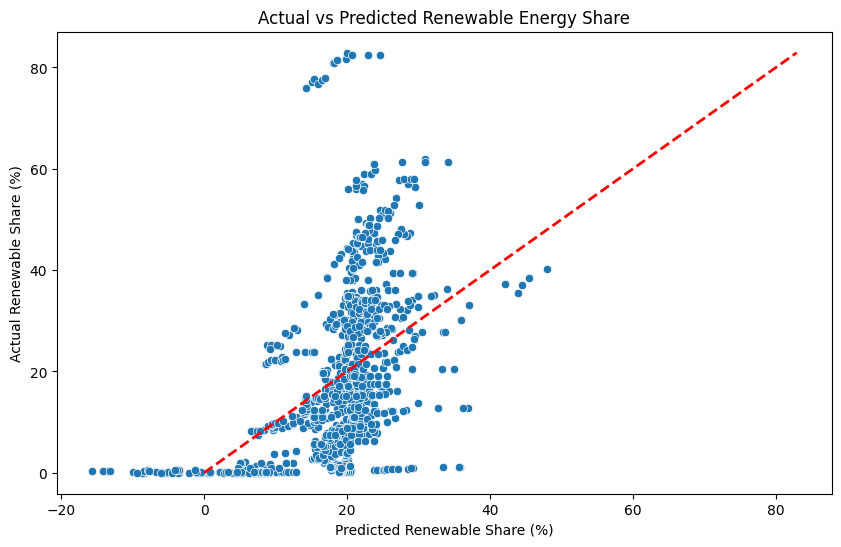

In [132]:
# Prepare variables for regression
# Target variable: Renewable_Share
# Explanatory variables: GDP_per_Capita, Electricity_Access, Urban_Population, CO2_Emissions, Energy_Consumption

X = df_clean[['GDP_per_Capita', 'Electricity_Access', 'Urban_Population', 'CO2_Emissions', 'Energy_Consumption']]
y = df_clean['Renewable_Share']

# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Display summary
print(model.summary())

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.predict(X), y=y)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Predicted Renewable Share (%)')
plt.ylabel('Actual Renewable Share (%)')
plt.title('Actual vs Predicted Renewable Energy Share')
plt.show()

### **Literature Support for Explanatory Variables**

| Variable | Literature Support / Reference | Key Argument |
| :--- | :--- | :--- |
| **GDP per Capita** | *Eyraud, L., Clements, B., & Wane, A. A. (2013)* | Higher income levels provide the financial capital required for high-upfront renewable energy projects. |
| **Electricity Access** | *Bhattacharyya, S. C. (2012)* | Countries expanding access often rely on centralized fossil fuel grids before transitioning to decentralized renewables. |
| **Urban Population** | *Li, K., & Lin, B. (2015)* | Urbanization drives industrial energy demand, which can influence the transition speed to cleaner sources. |
| **CO2 Emissions** | *Apergis, N., & Payne, J. E. (2010)* | High emissions act as a policy catalyst for 'Green Growth' and energy diversification. |
| **Energy Consumption** | *Intergovernmental Panel on Climate Change (IPCC). (2011)* | Total energy demand scale determines the feasibility of replacing traditional baseload power with intermittent renewables. |

### **Interpretation of Regression Results**

*   **R-squared (0.222):** This indicates that our model explains approximately 22.2% of the variance in Renewable Share. While low, this is common in global cross-country studies where political stability and local subsidies (not captured here) play a major role.
*   **CO2 Emissions (Coef: -1.25):** The highly significant negative coefficient suggests that for every unit increase in per capita CO2, the renewable share drops by 1.25%. This highlights a heavy reliance on carbon-intensive fuels in high-emitting nations.
*   **GDP per Capita (Coef: 0.0002):** Although positive and significant, the effect size is very small, suggesting wealth alone isn't a fast-track to renewable adoption without specific green policies.

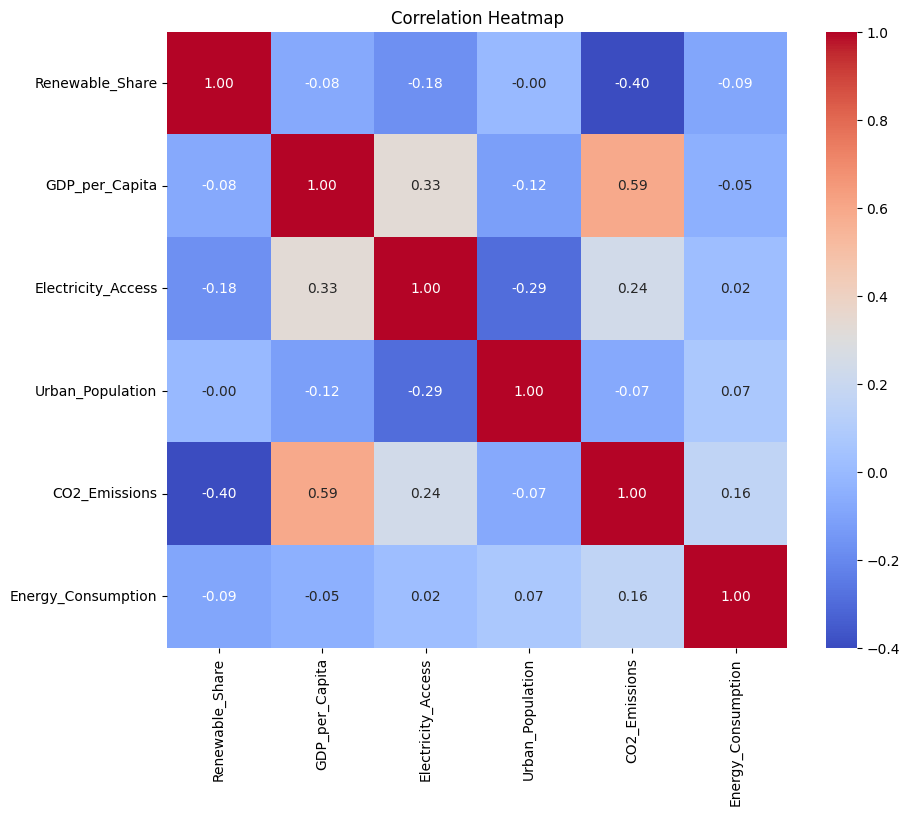


--- Variance Inflation Factor (VIF) ---


,Feature,VIF
0,GDP_per_Capita,4.681357
1,Electricity_Access,3.821221
2,Urban_Population,1.058092
3,CO2_Emissions,3.764078
4,Energy_Consumption,1.649692


In [133]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[['Renewable_Share', 'GDP_per_Capita', 'Electricity_Access', 'Urban_Population', 'CO2_Emissions', 'Energy_Consumption']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 2. Variance Inflation Factor (VIF)
# VIF > 10 generally indicates problematic multicollinearity
X_vif = df_clean[['GDP_per_Capita', 'Electricity_Access', 'Urban_Population', 'CO2_Emissions', 'Energy_Consumption']]
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- Variance Inflation Factor (VIF) ---")
display(vif_data)

### **5. Model Diagnostics: Checking OLS Assumptions**
To ensure our OLS model is the 'appropriate' choice (as per requirement 4), we must check for **Homoscedasticity** (constant variance of errors). If the errors show a pattern, a **Robust Regression** might be required.

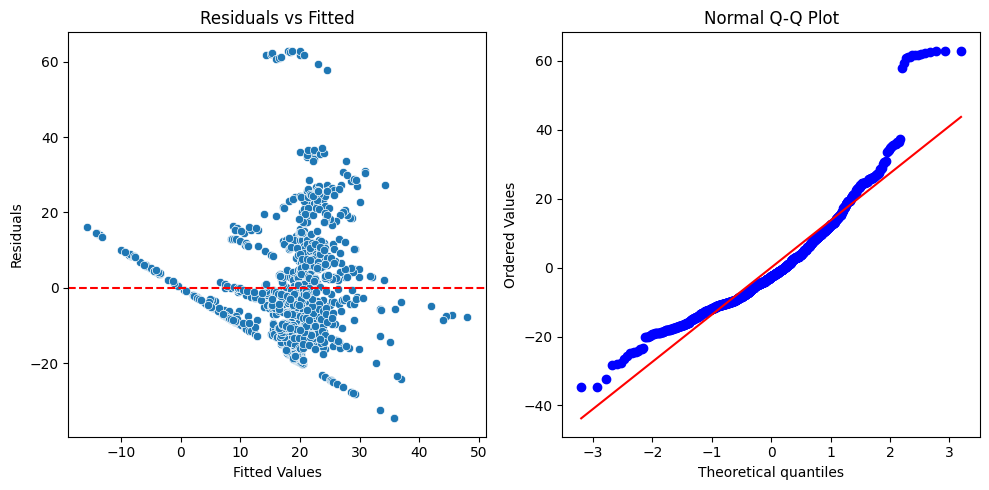

In [134]:
# 1. Residuals vs Fitted Plot (Checks for Homoscedasticity)
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# 2. Normal Q-Q Plot (Checks for Normality of Errors)
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()

### **7. Robust Regression (Alternative Model)**
Because the Q-Q plot and Jarque-Bera test suggest that the residuals are not normally distributed, we apply a **Robust Linear Model (RLM)**. This model is less sensitive to outliers and provides a more reliable estimation when OLS assumptions are violated.

In [135]:
# Fit Robust Linear Model
rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
print(rlm_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:        Renewable_Share   No. Observations:                  994
Model:                            RLM   Df Residuals:                      988
Method:                          IRLS   Df Model:                            5
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 31 May 2026                                         
Time:                        14:19:39                                         
No. Iterations:                    13                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 81.0678      9

### **6. Online Dashboard**
As per the project requirements, the interactive dashboard for this analysis can be accessed via the link below:

**Dashboard Link:** https://finals-ala-sraghzgrbuhhaaxlwatyeh.streamlit.app/